In [11]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

sys.path.append('../scripts')
import config
from data_pipeline import load_and_prepare_data, load_single_channel
import plots, xgb_scripts, evaluate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
all_channels = config.CHANNELS

all_channels_data = {}
for channel in all_channels:
      all_channels_data[channel] = load_single_channel(
                  "../../data/04-03-24", 
                  channel, (1, 200)
            )


In [22]:
# Extract end-of-cycle capacity for each channel (matching model pipeline behavior)
end_of_cycle_capacities = {}

for channel, df in all_channels_data.items():
    # Group by cycle and take the last capacity value for each cycle
    cycle_end_capacities = df.groupby('cycle number')['Capacity/mA.h'].last()
    end_of_cycle_capacities[channel] = cycle_end_capacities
    
    print(f"\nChannel {channel} - End-of-cycle capacity stats:")
    print(f"  Cycles: {len(cycle_end_capacities)}")
    print(f"  Range: {cycle_end_capacities.min():.1f} - {cycle_end_capacities.max():.1f} mAh")
    print(f"  Mean: {cycle_end_capacities.mean():.1f} mAh")
    print(f"  Std: {cycle_end_capacities.std():.1f} mAh")



Channel A1 - End-of-cycle capacity stats:
  Cycles: 200
  Range: 3050.0 - 4040.0 mAh
  Mean: 3525.2 mAh
  Std: 221.3 mAh

Channel A2 - End-of-cycle capacity stats:
  Cycles: 200
  Range: 2960.0 - 4040.0 mAh
  Mean: 3494.3 mAh
  Std: 238.3 mAh

Channel A3 - End-of-cycle capacity stats:
  Cycles: 200
  Range: 3140.0 - 3810.0 mAh
  Mean: 3474.6 mAh
  Std: 180.7 mAh

Channel A4 - End-of-cycle capacity stats:
  Cycles: 200
  Range: 2790.0 - 4010.0 mAh
  Mean: 3404.1 mAh
  Std: 289.7 mAh

Channel A5 - End-of-cycle capacity stats:
  Cycles: 200
  Range: 1190.0 - 3840.0 mAh
  Mean: 2992.3 mAh
  Std: 724.3 mAh

Channel A6 - End-of-cycle capacity stats:
  Cycles: 200
  Range: 3570.0 - 4050.0 mAh
  Mean: 3699.6 mAh
  Std: 104.9 mAh

Channel A7 - End-of-cycle capacity stats:
  Cycles: 200
  Range: 193.0 - 4020.0 mAh
  Mean: 2969.9 mAh
  Std: 805.7 mAh

Channel A8 - End-of-cycle capacity stats:
  Cycles: 200
  Range: 3340.0 - 4030.0 mAh
  Mean: 3592.1 mAh
  Std: 157.9 mAh


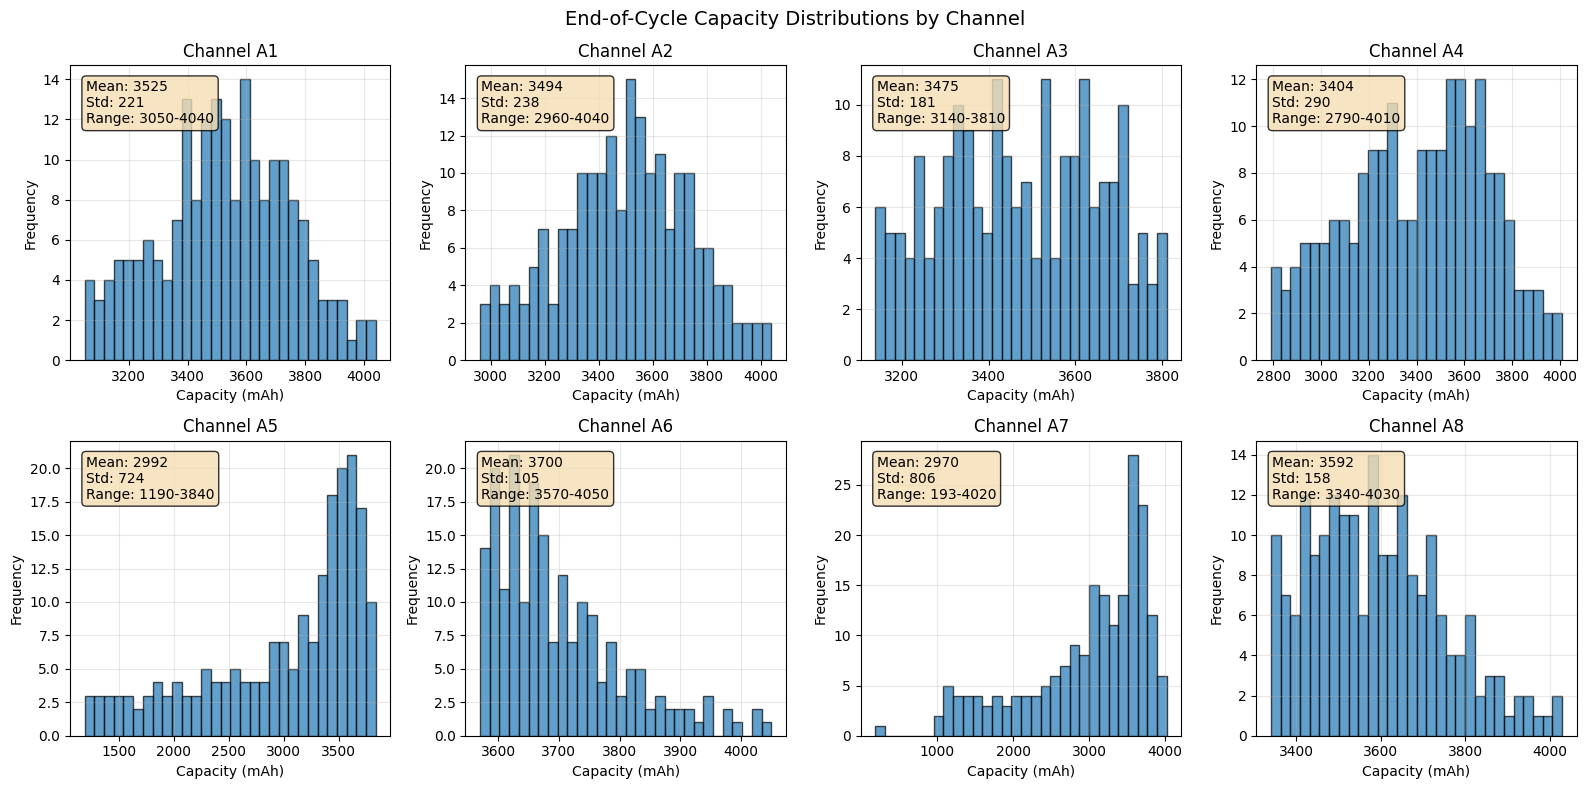

In [23]:
# Visualize end-of-cycle capacity distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('End-of-Cycle Capacity Distributions by Channel', fontsize=14)

for i, (channel, capacities) in enumerate(end_of_cycle_capacities.items()):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    if capacities is not None and len(capacities) > 0:
        ax.hist(capacities, bins=30, alpha=0.7, edgecolor='black')
        ax.set_title(f'Channel {channel}')
        ax.set_xlabel('Capacity (mAh)')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
        
        # Add stats text
        stats_text = f'Mean: {capacities.mean():.0f}\nStd: {capacities.std():.0f}\nRange: {capacities.min():.0f}-{capacities.max():.0f}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Channel {channel}')

plt.tight_layout()
plt.show()

In [24]:
# Compare train vs test channels end-of-cycle capacity
train_channels = config.TRAIN_CHANNELS
test_channels = config.TEST_CHANNELS

print("TRAIN CHANNELS (used for model training):")
train_capacities_all = []
for channel in train_channels:
    if channel in end_of_cycle_capacities:
        capacities = end_of_cycle_capacities[channel]
        train_capacities_all.extend(capacities.values)
        print(f"Channel {channel}: {capacities.min():.1f} - {capacities.max():.1f} mAh (mean: {capacities.mean():.1f})")

print(f"\nOverall Train Range: {np.min(train_capacities_all):.1f} - {np.max(train_capacities_all):.1f} mAh")

print("\n\nTEST CHANNELS (used for model testing):")
test_capacities_all = []
for channel in test_channels:
    if channel in end_of_cycle_capacities:
        capacities = end_of_cycle_capacities[channel]
        test_capacities_all.extend(capacities.values)
        print(f"Channel {channel}: {capacities.min():.1f} - {capacities.max():.1f} mAh (mean: {capacities.mean():.1f})")

print(f"\nOverall Test Range: {np.min(test_capacities_all):.1f} - {np.max(test_capacities_all):.1f} mAh")

TRAIN CHANNELS (used for model training):
Channel A1: 3050.0 - 4040.0 mAh (mean: 3525.2)
Channel A2: 2960.0 - 4040.0 mAh (mean: 3494.3)
Channel A3: 3140.0 - 3810.0 mAh (mean: 3474.6)
Channel A4: 2790.0 - 4010.0 mAh (mean: 3404.1)
Channel A7: 193.0 - 4020.0 mAh (mean: 2969.9)
Channel A8: 3340.0 - 4030.0 mAh (mean: 3592.1)

Overall Train Range: 193.0 - 4040.0 mAh


TEST CHANNELS (used for model testing):
Channel A2: 2960.0 - 4040.0 mAh (mean: 3494.3)
Channel A5: 1190.0 - 3840.0 mAh (mean: 2992.3)

Overall Test Range: 1190.0 - 4040.0 mAh
